In [1]:
import numpy as np
import pandas as pd
import rasterio

from tqdm import tqdm
from config import config
from xgboost import XGBClassifier
from joblib import Parallel, delayed
from utils import (
    build_metadata, plot_class_distribution, split_metadata,
    print_split_summary, refine_mask_small_components, build_pixel_quality_mask,
    encode_labels, count_by_class, evaluate_split, sample_pixels
)


In [2]:
def normalized_diff(a, b, eps=1e-6):
    return (a - b) / (a + b + eps)

def preprocess_img(img_path, mask_path):
    with rasterio.open(img_path) as src:
        img = src.read().astype(np.float32)
    with rasterio.open(mask_path) as src:
        mask = src.read(1)
        if src.count >= 2:
            confidence = src.read(2).astype(np.float32)
        else:
            confidence = np.full(mask.shape, 100.0, dtype=np.float32)
    
    refined_mask, refined_confidence, _ = refine_mask_small_components(
        mask,
        confidence=confidence,
        return_details=True,
        **config.REFINE_KWARGS,
    )
    img = np.clip(img, 0, 10000) / 10000.0
    pixel_valid = build_pixel_quality_mask(img)

    refined_mask = refined_mask.copy()
    refined_mask[~pixel_valid] = 0

    confidence = np.where(
        pixel_valid,
        np.clip(refined_confidence / 100.0, config.CONFIDENCE_FLOOR, 1.0),
        0.0,
    ).astype(np.float32)
    return img, refined_mask, confidence, pixel_valid

def extract_features(img):
    b_raw = img.astype(np.float32)

    blue = b_raw[1]
    green = b_raw[2]
    red = b_raw[3]
    nir = b_raw[7]
    swir1 = b_raw[10]
    swir2 = b_raw[11]

    bands_mean = np.mean(b_raw, axis=0)
    bands_std = np.std(b_raw, axis=0)
    brightness = np.mean(b_raw[[1, 2, 3]], axis=0)
    visible_std = np.std(b_raw[[1, 2, 3]], axis=0)

    ndvi = normalized_diff(nir, red)
    ndwi = normalized_diff(green, nir)
    mndwi = normalized_diff(green, swir1)
    ndbi = normalized_diff(swir1, nir)
    ndmi = normalized_diff(nir, swir1)
    nbr = normalized_diff(nir, swir2)
    bsi = ((swir1 + red) - (nir + blue)) / ((swir1 + red) + (nir + blue) + 1e-6)
    savi = 1.5 * (nir - red) / (nir + red + 0.5 + 1e-6)
    evi = 2.5 * (nir - red) / (nir + 6.0 * red - 7.5 * blue + 1.0 + 1e-6)

    nir_red_ratio = nir / (red + 1e-6)
    red_green_ratio = red / (green + 1e-6)
    blue_green_ratio = blue / (green + 1e-6)
    swir_ratio = swir1 / (swir2 + 1e-6)

    features = np.concatenate(
        [
            b_raw,
            ndvi[np.newaxis, ...],
            ndwi[np.newaxis, ...],
            mndwi[np.newaxis, ...],
            ndbi[np.newaxis, ...],
            ndmi[np.newaxis, ...],
            nbr[np.newaxis, ...],
            bsi[np.newaxis, ...],
            savi[np.newaxis, ...],
            evi[np.newaxis, ...],
            brightness[np.newaxis, ...],
            visible_std[np.newaxis, ...],
            bands_mean[np.newaxis, ...],
            bands_std[np.newaxis, ...],
            nir_red_ratio[np.newaxis, ...],
            red_green_ratio[np.newaxis, ...],
            blue_green_ratio[np.newaxis, ...],
            swir_ratio[np.newaxis, ...],
        ],
        axis=0,
    )

    feature_names = [f'B{i + 1}' for i in range(b_raw.shape[0])] + [
        'ndvi',
        'ndwi',
        'mndwi',
        'ndbi',
        'ndmi',
        'nbr',
        'bsi',
        'savi',
        'evi',
        'brightness',
        'visible_std',
        'bands_mean',
        'bands_std',
        'nir_red_ratio',
        'red_green_ratio',
        'blue_green_ratio',
        'swir_ratio',
    ]

    return features, feature_names


def process_pair(img_path, mask_path):
    img, mask, confidence, pixel_valid = preprocess_img(img_path, mask_path)
    features, feature_names = extract_features(img)

    valid = pixel_valid & (mask != 0) & (confidence * 100.0 >= config.MIN_CONFIDENCE)
    X = features[:, valid].T.astype(np.float32)
    y = mask[valid].reshape(-1).astype(np.uint8)
    pixel_weight = confidence[valid].reshape(-1).astype(np.float32)

    return X, y, pixel_weight, feature_names


def build_dataset(split_df, n_jobs=-1):
    records = split_df[['img_path', 'mask_path']].to_dict('records')
    results = Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(process_pair)(row['img_path'], row['mask_path'])
        for row in tqdm(records, desc='Building dataset')
    )

    X_parts = []
    y_parts = []
    weight_parts = []
    feature_names = None

    for X, y, pixel_weight, names in results:
        X_parts.append(X)
        y_parts.append(y)
        weight_parts.append(pixel_weight)
        if feature_names is None:
            feature_names = names

    X_all = np.concatenate(X_parts, axis=0)
    y_all = np.concatenate(y_parts, axis=0)
    weight_all = np.concatenate(weight_parts, axis=0)
    return X_all, y_all, weight_all, feature_names

In [3]:
meta = build_metadata(config.DATA_DIR)
train_meta, val_meta, test_meta = split_metadata(meta)

print_split_summary('train', train_meta)
print_split_summary('val', val_meta)
print_split_summary('test', test_meta)

Scanning masks: 100%|██████████| 300/300 [00:00<00:00, 608.48it/s]

[train] images: 210
  Unknown  pixels=    5,793 images= 74
  Greenery pixels=9,147,871 images=198
  Sand     pixels=3,666,708 images=174
  Water    pixels=  368,670 images= 33
  Cement   pixels=  573,518 images=164
  strata: {'cement_only': 135, 'base': 42, 'water_and_cement': 29, 'water_only': 4}
[val] images: 45
  Unknown  pixels=      110 images=  7
  Greenery pixels=2,049,097 images= 42
  Sand     pixels=  844,585 images= 38
  Water    pixels=   24,787 images=  7
  Cement   pixels=   30,541 images= 35
  strata: {'cement_only': 29, 'base': 9, 'water_and_cement': 6, 'water_only': 1}
[test] images: 45
  Unknown  pixels=    3,921 images= 19
  Greenery pixels=1,748,660 images= 43
  Sand     pixels=  905,788 images= 38
  Water    pixels=   30,064 images=  8
  Cement   pixels=  260,687 images= 35
  strata: {'cement_only': 28, 'base': 9, 'water_and_cement': 7, 'water_only': 1}


In [4]:
print(train_meta.head())

  sample_id               img_path                mask_path  total_pixels  \
0        62   data/imgs/img_62.tif   data/masks/mask_62.tif         65536   
1       235  data/imgs/img_235.tif  data/masks/mask_235.tif         65536   
2       131  data/imgs/img_131.tif  data/masks/mask_131.tif         65536   
3       236  data/imgs/img_236.tif  data/masks/mask_236.tif         65536   
4       195  data/imgs/img_195.tif  data/masks/mask_195.tif         65536   

   has_water  has_cement  has_sand  count_0  count_1  count_2  count_3  \
0          0           0         1        0    65532        4        0   
1          1           1         1        6     9942    55555        6   
2          0           1         1        0    53280    10670        0   
3          0           1         1       99    40699    24689        0   
4          0           1         1        0    64984      115        0   

   count_4           stratum  
0        0              base  
1       27  water_and_cement  

Building dataset: 100%|██████████| 45/45 [00:00<00:00, 132.65it/s]


Train full: (13667990, 29) {'Greenery': 9150944, 'Sand': 3633538, 'Water': 308800, 'Cement': 574708}
Val      : (2949120, 29) {'Greenery': 2049206, 'Sand': 844586, 'Water': 24787, 'Cement': 30541}
Test     : (2947585, 29) {'Greenery': 1749810, 'Sand': 906185, 'Water': 30723, 'Cement': 260867}
Train confidence weight range: 0.33000001311302185 1.0
Greenery available=9,150,944 sampled=  400,000
Sand     available=3,633,538 sampled=  400,000
Water    available=  308,800 sampled=  308,800
Cement   available=  574,708 sampled=  574,708
Greenery available=2,049,206 sampled=  200,000
Sand     available=  844,586 sampled=  200,000
Water    available=   24,787 sampled=   24,787
Cement   available=   30,541 sampled=   30,541
Greenery available=1,749,810 sampled=  200,000
Sand     available=  906,185 sampled=  200,000
Water    available=   30,723 sampled=   30,723
Cement   available=  260,867 sampled=  260,867
Train sampled: (1683508, 29) {'Greenery': 400000, 'Sand': 400000, 'Water': 308800, 'Cem

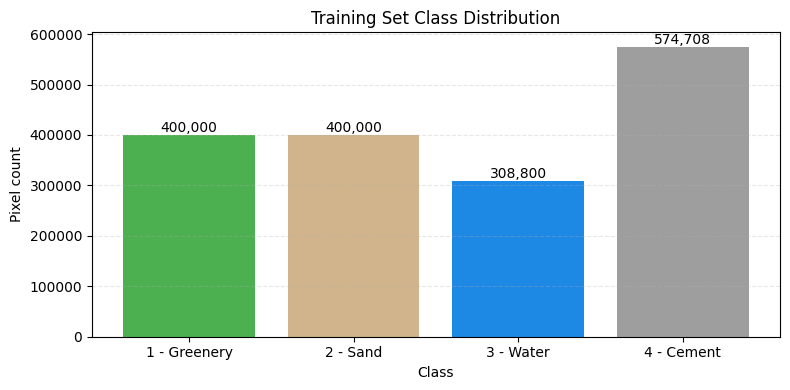

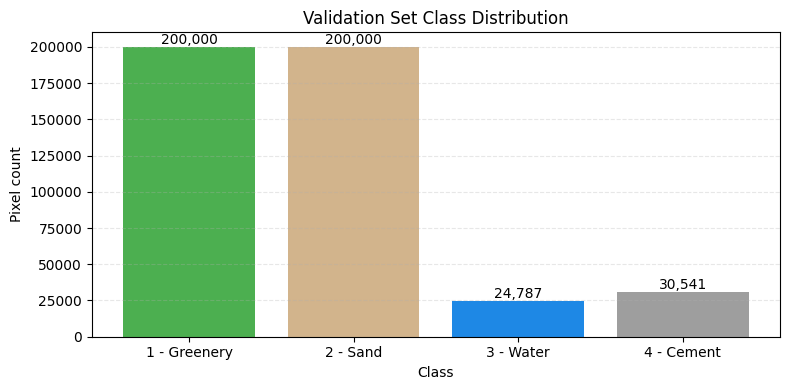

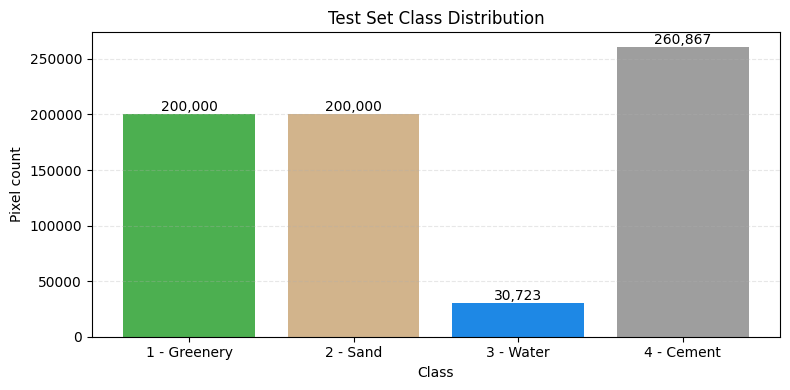

In [5]:
X_train_full, y_train_full, conf_train_full, feature_names = build_dataset(train_meta)
X_val, y_val, _, _ = build_dataset(val_meta)
X_test, y_test, _, _ = build_dataset(test_meta)

print('Train full:', X_train_full.shape, count_by_class(y_train_full))
print('Val      :', X_val.shape, count_by_class(y_val))
print('Test     :', X_test.shape, count_by_class(y_test))
print('Train confidence weight range:', float(conf_train_full.min()), float(conf_train_full.max()))

X_train, y_train, conf_train = sample_pixels(X_train_full, y_train_full, conf_train_full, caps=config.TRAIN_CAPS)
X_val, y_val, _ = sample_pixels(X_val, y_val, np.ones_like(y_val), caps=config.VAL_TEST_CAPS)
X_test, y_test, _ = sample_pixels(X_test, y_test, np.ones_like(y_test), caps=config.VAL_TEST_CAPS)
print('Train sampled:', X_train.shape, count_by_class(y_train))
print('Val sampled  :', X_val.shape, count_by_class(y_val))
print('Test sampled :', X_test.shape, count_by_class(y_test))
plot_class_distribution(y_train, 'Training Set Class Distribution')
plot_class_distribution(y_val, 'Validation Set Class Distribution')
plot_class_distribution(y_test, 'Test Set Class Distribution')

In [6]:
y_train_enc = encode_labels(y_train)
sample_weight = conf_train.copy()
sample_weight[y_train == 3] *= config.WATER_WEIGHT_MULTIPLIER
sample_weight[y_train == 4] *= config.CEMENT_WEIGHT_MULTIPLIER
print('Weighted classes:', {
    'Water': config.WATER_WEIGHT_MULTIPLIER,
    'Cement': config.CEMENT_WEIGHT_MULTIPLIER,
})

model = XGBClassifier(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.80,
    colsample_bytree=0.80,
    min_child_weight=3,
    reg_alpha=0.05,
    reg_lambda=1.5,
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    tree_method='hist',
    n_jobs=-1,
    random_state=config.RANDOM_STATE,
)

model.fit(X_train, y_train_enc, sample_weight=sample_weight)


Weighted classes: {'Water': 3.0, 'Cement': 2.0}


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

===== Train =====
              precision    recall  f1-score   support

           1     0.8521    0.8752    0.8635    400000
           2     0.9188    0.8436    0.8796    400000
           3     0.9816    0.9978    0.9897    308800
           4     0.9182    0.9451    0.9315    574708

    accuracy                         0.9140   1683508
   macro avg     0.9177    0.9154    0.9160   1683508
weighted avg     0.9143    0.9140    0.9137   1683508

Confusion Matrix:
 [[350080  20633   4254  25033]
 [ 38601 337425    709  23265]
 [   573     13 308132     82]
 [ 21596   9170    799 543143]]
mIoU: 0.849017821180282
Per-class IoU: {'Greenery': 0.7597716865247304, 'Sand': 0.785045228655983, 'Water': 0.9795588786948201, 'Cement': 0.8716954908455948}


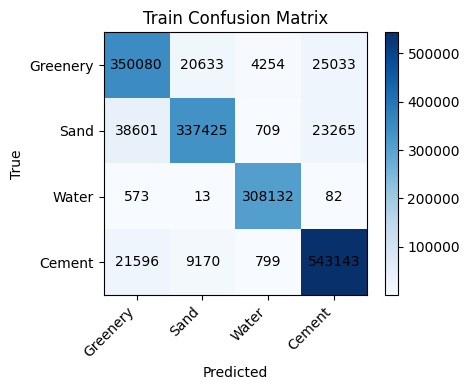

(array([[350080,  20633,   4254,  25033],
        [ 38601, 337425,    709,  23265],
        [   573,     13, 308132,     82],
        [ 21596,   9170,    799, 543143]]),
 0.849017821180282,
 array([0.75977169, 0.78504523, 0.97955888, 0.87169549]))

In [7]:
evaluate_split("Train", model, X_train, y_train)

===== Validation =====
              precision    recall  f1-score   support

           1     0.8274    0.8927    0.8588    200000
           2     0.9362    0.8135    0.8705    200000
           3     0.8239    0.9741    0.8927     24787
           4     0.5343    0.6375    0.5814     30541

    accuracy                         0.8452    455328
   macro avg     0.7804    0.8295    0.8009    455328
weighted avg     0.8553    0.8452    0.8472    455328

Confusion Matrix:
 [[178542   6916   4673   9869]
 [ 29957 162697    343   7003]
 [   535      8  24146     98]
 [  6763   4163    145  19470]]
mIoU: 0.6848385353757531
Per-class IoU: {'Greenery': 0.7525320857305431, 'Sand': 0.7707580286801177, 'Water': 0.806264191264859, 'Cement': 0.4097998358274926}


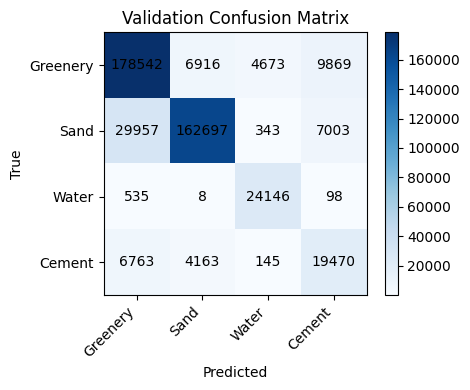

(array([[178542,   6916,   4673,   9869],
        [ 29957, 162697,    343,   7003],
        [   535,      8,  24146,     98],
        [  6763,   4163,    145,  19470]]),
 0.6848385353757531,
 array([0.75253209, 0.77075803, 0.80626419, 0.40979984]))

In [8]:
evaluate_split('Validation', model, X_val, y_val)

===== Test =====
              precision    recall  f1-score   support

           1     0.7423    0.7062    0.7238    200000
           2     0.8069    0.6990    0.7491    200000
           3     0.6678    0.7491    0.7061     30723
           4     0.8143    0.9165    0.8624    260867

    accuracy                         0.7853    691590
   macro avg     0.7578    0.7677    0.7603    691590
weighted avg     0.7848    0.7853    0.7826    691590

Confusion Matrix:
 [[141231  18852   9090  30827]
 [ 35878 139806   1186  23130]
 [  6412    742  23014    555]
 [  6752  13870   1170 239075]]
mIoU: 0.6174357205761232
Per-class IoU: {'Greenery': 0.5670971161490833, 'Sand': 0.5988332248226708, 'Water': 0.5457563613080699, 'Cement': 0.7580561800246687}


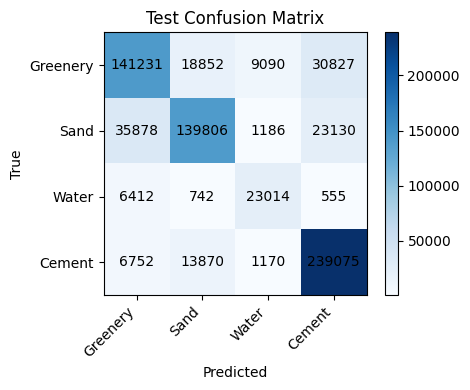

(array([[141231,  18852,   9090,  30827],
        [ 35878, 139806,   1186,  23130],
        [  6412,    742,  23014,    555],
        [  6752,  13870,   1170, 239075]]),
 0.6174357205761232,
 array([0.56709712, 0.59883322, 0.54575636, 0.75805618]))

In [9]:
evaluate_split('Test', model, X_test, y_test)

In [10]:
importance_df = pd.DataFrame(
    {
        'feature': feature_names,
        'importance': model.feature_importances_,
    }
).sort_values('importance', ascending=False)

display(importance_df.head(20))

,feature,importance
10,B11,0.249840
11,B12,0.195994
13,ndwi,0.089957
19,savi,0.085889
24,bands_std,0.054026
25,nir_red_ratio,0.042556
12,ndvi,0.041630
14,mndwi,0.036565
28,swir_ratio,0.027436
26,red_green_ratio,0.020026
